# E48 · Regimes and extremes in a seasonal chaotic atmosphere: a Bayesian NHMM for Lorenz-84, and a test of NHMM-triggered control

| | |
|---|---|
| **Type** | Advanced worked example - read, run, modify |
| **Data** | Simulated: the **Lorenz (1984)** model of the mid-latitude circulation (a jet and a travelling eddy) with a **seasonal cycle** in the equator-to-pole temperature gradient (Lorenz 1990), observed once a day with multiplicative error - the setting of Liu, Huang & Lall (2026), *Physical Review E* 113, 064207, "Regime identification and control of extremes in the nonautonomous Lorenz model with chaos and intransitivity" |
| **You will learn** | A **nonautonomous** chaotic system: seasonal forcing, when eddy extremes happen, and what the local Lyapunov exponent looks like through the year · choosing what a regime *is* (the eddy's amplitude, not its phase) · a **nonhomogeneous hidden Markov model** (NHMM) in PyMC: state-dependent AR(1) emissions, transition probabilities that follow the season through a softmax on $\sin$/$\cos$ covariates, the forward algorithm in `scan` · HMM **multimodality**: several MAP optima, chains in different modes, and starting from the best of a multi-start search · how many regimes? (held-out one-step-ahead log score) · decoding, seasonal transition curves with uncertainty, and a **danger score** $\sum_h \frac1h P(\text{dangerous regime at } t+h)$ · does the NHMM trigger coincide with high local instability, as the paper reports? · **control through the statistical model**: minimise the danger score over a bounded nudge, applied to the true system · the tests that decide whether it works: a **random-direction placebo** of the same size, and a **simple threshold rule** |

## The question, in one paragraph

Weather extremes cluster in *regimes*: persistent patterns of the jet stream that make heat
waves, floods or storms more likely. If a model could say, a few days ahead, "the atmosphere
is about to enter a dangerous regime", and if the atmosphere is chaotic enough that small
pushes have large effects, then one could imagine steering away from the danger ("weather
jiu-jitsu", E47). Liu, Huang & Lall test the idea on Lorenz's 1984 toy atmosphere with a
seasonal cycle. Their controller is statistical: a hidden Markov model whose regime transition
probabilities change with the season recognises dangerous regimes from noisy observations and
chooses a nudge that lowers the predicted probability of entering one. This notebook builds that
model the Bayesian way and then asks the question every intervention study needs to answer:
**does it beat doing something simpler, or doing something random of the same size?**

## The plan

1. Lorenz-84 with a seasonal cycle
2. Observations, and what a regime should be
3. A Bayesian NHMM, and the trouble with HMM likelihoods
4. How many regimes? What they look like, and how they follow the season
5. A danger score, and its link to local instability
6. Control through the NHMM - and the tests it has to pass

In [1]:
import logging
import time

import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pymc as pm
import pytensor
import pytensor.tensor as pt
from scipy.optimize import minimize
from scipy.special import logsumexp, softmax

RANDOM_SEED = 48
rng = np.random.default_rng(RANDOM_SEED)
az.style.use("arviz-variat")
logging.getLogger("pymc").setLevel(logging.WARNING)
BLUE, ORANGE, AQUA, GREY, PURPLE, RED, INK = (
    "#2a78d6", "#eb6834", "#1baf7a", "#8a8a86", "#8c5ac8", "#c8384e", "#222222")
STATE_COLOURS = [BLUE, AQUA, RED, PURPLE]
print(f"PyMC {pm.__version__}, ArviZ {az.__version__}, PyTensor {pytensor.__version__}")

PyMC 6.3.2, ArviZ 1.3.0, PyTensor 3.3.2


## 1 · Lorenz-84 with a seasonal cycle

Lorenz (1984) boiled the mid-latitude circulation down to three variables: $x$ is the strength
of the westerly **jet**, and $y$, $z$ are the cosine and sine amplitudes of a large travelling
**eddy** (a chain of highs and lows):

$$\dot x = -y^2 - z^2 - a x + a F(t), \qquad \dot y = x y - b x z - y + G, \qquad
  \dot z = b x y + x z - z .$$

The eddy grows by drawing energy from the jet ($x y$, $x z$; the $-y^2 - z^2$ in the jet
equation is the jet's loss), and is carried along by it ($b x z$, $b x y$). $F$ is the
equator-to-pole temperature contrast that drives the jet and $G$ the land-sea contrast. We use the
standard $a = 0.25$, $b = 4$, $G = 1$ and, following Lorenz (1990) and the paper, a seasonal
cycle $F(t) = 7 + 2\cos(2\pi t / 73)$: one time unit is about five days, so a year is 73 units,
with $F = 9$ in mid-winter and $F = 5$ in mid-summer. We integrate with RK4, $\Delta t = 0.01$,
and record the state once a "day" (0.2 time units, 20 steps), for eight years.

extreme-eddy threshold E* (90th percentile of |y|+|z|): 2.22
share of days above E* by month from mid-winter: [0.23 0.19 0.12 0.07 0.03 0.01 0.03 0.1  0.06 0.1  0.12 0.19]


correlation of LLE with eddy amplitude: 0.90


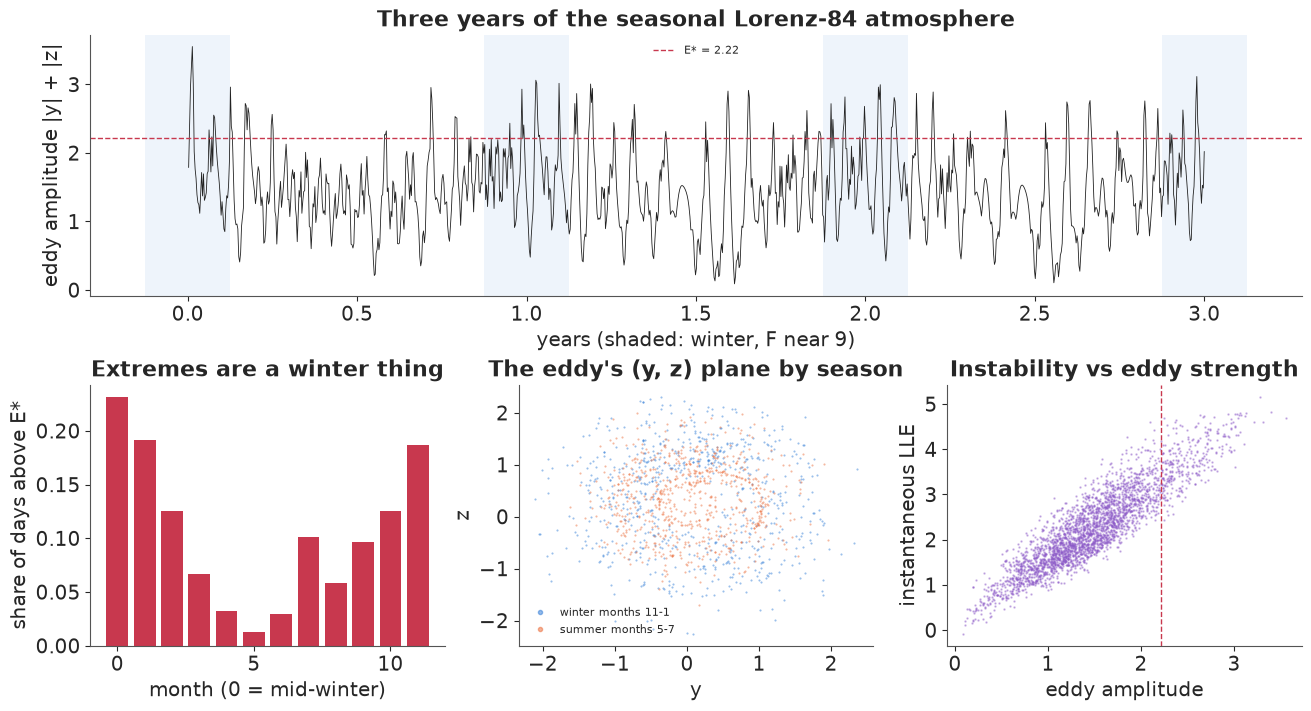

In [2]:
A_, B_, G_, F0, F1, YEAR, DT, STEPS_PER_DAY = 0.25, 4.0, 1.0, 7.0, 2.0, 73.0, 0.01, 20


def forcing(t):
    return F0 + F1 * np.cos(2 * np.pi * t / YEAR)


def lorenz84(s, t):
    x, y, z = s[..., 0], s[..., 1], s[..., 2]
    return np.stack([-y**2 - z**2 - A_ * x + A_ * forcing(t),
                     x * y - B_ * x * z - y + G_,
                     B_ * x * y + x * z - z], axis=-1)


def rk4(s, t):
    k1 = lorenz84(s, t)
    k2 = lorenz84(s + DT / 2 * k1, t + DT / 2)
    k3 = lorenz84(s + DT / 2 * k2, t + DT / 2)
    k4 = lorenz84(s + DT * k3, t + DT)
    return s + DT / 6 * (k1 + 2 * k2 + 2 * k3 + k4)


def local_lyapunov(s):
    """Largest eigenvalue of the symmetric part of the Jacobian (the paper's LLE)."""
    x, y, z = s[..., 0], s[..., 1], s[..., 2]
    o = np.zeros_like(x)
    J = np.stack([np.stack([o - A_, -2 * y, -2 * z], -1),
                  np.stack([y - B_ * z, x - 1, -B_ * x], -1),
                  np.stack([B_ * y + z, B_ * x, x - 1], -1)], -2)
    return np.linalg.eigvalsh(0.5 * (J + np.swapaxes(J, -1, -2)))[..., -1]


def eddy_amplitude(s):
    return np.abs(s[..., 1]) + np.abs(s[..., 2])          # the paper's |y| + |z|


N_YEARS = 8
n_days = int(N_YEARS * 365)
s, t = np.array([2.4, 1.0, 0.0]), 0.0                       # Lorenz (1990)'s initial state
days = np.empty((n_days, 3))
t_day = np.empty(n_days)
fine_eddy, fine_lle, fine_t = [], [], []
for d in range(n_days):
    for _ in range(STEPS_PER_DAY):
        s = rk4(s, t)
        t += DT
        fine_eddy.append(eddy_amplitude(s))
        fine_t.append(t)
    days[d], t_day[d] = s, t
fine_eddy, fine_t = np.array(fine_eddy), np.array(fine_t)
E_STAR = np.quantile(fine_eddy, 0.9)
season = (t_day % YEAR) / YEAR                               # 0 = mid-winter (F = 9)
month = (season * 12).astype(int)
eddy_day = eddy_amplitude(days)
lle_day = local_lyapunov(days)
print(f"extreme-eddy threshold E* (90th percentile of |y|+|z|): {E_STAR:.2f}")
print("share of days above E* by month from mid-winter:",
      np.round([np.mean(eddy_day[month == m] > E_STAR) for m in range(12)], 2))

fig = plt.figure(figsize=(13, 7))
gs = fig.add_gridspec(2, 3)
ax = fig.add_subplot(gs[0, :])
show = slice(0, 3 * 365)
ax.plot(t_day[show] / YEAR, eddy_day[show], color=INK, lw=0.6)
ax.axhline(E_STAR, color=RED, lw=1, ls="--", label=f"E* = {E_STAR:.2f}")
for yr in range(4):
    ax.axvspan(yr - 0.125, yr + 0.125, color=BLUE, alpha=0.08, lw=0)
ax.set(xlabel="years (shaded: winter, F near 9)", ylabel="eddy amplitude |y| + |z|",
       title="Three years of the seasonal Lorenz-84 atmosphere")
ax.legend(fontsize=8)
ax = fig.add_subplot(gs[1, 0])
ax.bar(np.arange(12), [np.mean(eddy_day[month == m] > E_STAR) for m in range(12)], color=RED)
ax.set(xlabel="month (0 = mid-winter)", ylabel="share of days above E*", title="Extremes are a winter thing")
ax = fig.add_subplot(gs[1, 1])
for lo, hi, c, lab in [(0, 1, BLUE, "winter months 11-1"), (5, 7, ORANGE, "summer months 5-7")]:
    sel = (month >= lo) & (month <= hi) if lo else (month <= 1) | (month == 11)
    ax.plot(days[sel, 1], days[sel, 2], ".", ms=1, color=c, alpha=0.5, label=lab)
ax.set(xlabel="y", ylabel="z", title="The eddy's (y, z) plane by season")
ax.legend(fontsize=8, markerscale=6)
ax = fig.add_subplot(gs[1, 2])
ax.plot(eddy_day, lle_day, ".", ms=1.5, color=PURPLE, alpha=0.4)
ax.axvline(E_STAR, color=RED, lw=1, ls="--")
ax.set(xlabel="eddy amplitude", ylabel="instantaneous LLE", title="Instability vs eddy strength");
print(f"correlation of LLE with eddy amplitude: {np.corrcoef(lle_day, eddy_day)[0, 1]:.2f}")

The forcing makes the system **nonautonomous**: the attractor itself changes through the year.
In winter the strong temperature contrast drives a strong jet whose eddies grow large and
irregular, and most days above the extreme-eddy threshold $E^*$ fall in the winter months; in
summer the eddy settles into smaller, more regular circuits. The local Lyapunov exponent
(largest eigenvalue of the symmetric Jacobian, as in the paper and in E47) rises with the eddy
amplitude: the strongest eddies are also where the flow is most unstable.

## 2 · Observations, and what a regime should be

We observe all three variables once a day with 5% multiplicative error (plus a small floor),
as the paper does, and keep years 1-3 for fitting, year 4 for choosing the number of regimes,
and the rest as fresh weather for the control experiments.

The paper's NHMM uses $x$, $y$ and $z$ directly. But $y$ and $z$ are the *phases* of a
travelling wave: the same eddy, a quarter-turn later, has swapped $y$ and $z$. A regime should
describe *how strong* the eddy is, not where it happens to be in its orbit, and phase variables
make the emission model fit the rotation instead of the regime. We therefore describe each day
by the **jet** $x$ and the **log eddy amplitude** $\log\sqrt{y^2 + z^2}$. (A first attempt on
$x, y, z$ gave chains stuck in different modes with $\hat R \approx 1.7$.)

In [3]:
obs_rng = np.random.default_rng(1)
obs = days * (1 + 0.05 * obs_rng.standard_normal(days.shape)) + 0.02 * obs_rng.standard_normal(days.shape)


def features(s):
    """(..., 3) states -> (..., 2) = (jet x, log eddy amplitude)."""
    return np.stack([s[..., 0], np.log(np.hypot(s[..., 1], s[..., 2]))], axis=-1)


V = features(obs)
TRAIN, VALID = slice(0, 3 * 365), slice(3 * 365, 4 * 365)
C_all = np.stack([np.sin(2 * np.pi * t_day / YEAR), np.cos(2 * np.pi * t_day / YEAR)], axis=1)
print(f"training days {TRAIN.stop}, validation days {VALID.stop - VALID.start}")

training days 1095, validation days 365


## 3 · A Bayesian NHMM, and the trouble with HMM likelihoods

The model has $K$ hidden regimes $S_t$. Given the regime, each feature follows an AR(1) around
a regime-specific level,

$$v_{d,t} \mid S_t = k \;\sim\; N\big(m_{k,d} + \phi_{k,d}\,(v_{d,t-1} - m_{k,d}),\ \sigma_{k,d}^2\big),
  \qquad d \in \{\text{jet},\ \text{log eddy}\},$$

and the regime moves with **seasonal** transition probabilities: for a move from $i$ to
$j \ne i$ the logit is $\beta_{0,ij} + \beta_{1,ij}^\top (\sin 2\pi t/73,\ \cos 2\pi t/73)$, with
"stay" as the reference (logit 0) and a softmax over each row. The regimes are summed out by the
**forward algorithm** (E24), whose loop over days is a `pytensor.scan`. Priors: levels
$N(1, 1)$ for the jet and $N(0.3, 1)$ for the log amplitude; persistence $\phi \sim
\text{Beta}(5, 2)$; log noise sd $N(\log 0.2, 1)$; $\beta_0 \sim N(-3, 1.5)$ (leaving a regime
on a given day is unlikely a priori, $e^{-3} \approx 5\%$) and $\beta_1 \sim N(0, 1)$. To make
the labels identifiable the regimes are **ordered by their eddy level** (PyMC's `ordered`
transform): regime 0 has the weakest eddies, regime $K-1$ the strongest. (A first version
imposed the order with a `-inf` `Potential`; that hard wall gave the 4-regime model 1,700
divergences. The transform gave 1.)

In [4]:
def build_nhmm(K, v, C):
    with pm.Model() as model:
        level_jet = pm.Normal("level_jet", 1.0, 1.0, shape=K)
        level_eddy = pm.Normal("level_eddy", 0.3, 1.0, shape=K,          # ordered: labels identified
                               transform=pm.distributions.transforms.ordered,
                               initval=np.linspace(-0.5, 0.6, K))
        level = pm.Deterministic("level", pt.stack([level_jet, level_eddy], axis=1))
        phi = pm.Beta("phi", 5, 2, shape=(K, 2))
        log_sd = pm.Normal("log_sd", np.log(0.2), 1, shape=(K, 2))
        mean = level[None] + phi[None] * (v[:-1, None, :] - level[None])
        log_emis = pm.logp(pm.Normal.dist(mean, pt.exp(log_sd)[None]), v[1:, None, :]).sum(-1)
        b0 = pm.Normal("b0", -3, 1.5, shape=(K, K))
        b1 = pm.Normal("b1", 0, 1, shape=(K, K, 2))
        off = 1 - np.eye(K)
        eta = (b0[None] + (b1[None] * C[1:-1, None, None, :]).sum(-1)) * off   # (T-2, K, K)
        log_G = eta - pt.logsumexp(eta, axis=-1, keepdims=True)

        def step(log_e_t, log_G_t, log_alpha):
            return log_e_t + pt.logsumexp(log_alpha[:, None] + log_G_t, axis=0)

        log_alpha = pytensor.scan(step, sequences=[log_emis[1:], log_G],
                                  outputs_info=[np.log(np.full(K, 1 / K)) + log_emis[0]],
                                  return_updates=False)
        pm.Potential("loglik", pt.logsumexp(log_alpha[-1]))
    return model


def multistart_map(model, K, n_starts=10):
    """MAP from several random starts; returns all log-posteriors and the best point."""
    logp_fn = model.compile_logp()
    results = []
    for k in range(n_starts):
        r = np.random.default_rng(k)
        start = {"level_jet": r.normal(1, 0.8, K), "level_eddy": np.sort(r.normal(0.3, 0.5, K))}
        point = pm.find_MAP(model=model, start=start, progressbar=False, seed=k)
        results.append((float(logp_fn({v.name: point[v.name] for v in model.value_vars})), point))
    return [lp for lp, _ in results], max(results, key=lambda x: x[0])[1]


def fit_nhmm(K, seed=RANDOM_SEED):
    model = build_nhmm(K, V[TRAIN], C_all[TRAIN])
    optima, best = multistart_map(model, K)
    with model:
        idata = pm.sample(random_seed=seed, progressbar=False,
                          initvals={k: best[k] for k in ["level_jet", "level_eddy", "phi", "log_sd", "b0", "b1"]})
    return model, idata, optima


t0 = time.time()
fits = {K: fit_nhmm(K) for K in (2, 3, 4)}
print(f"three NHMMs fitted in {time.time() - t0:.0f} s")
for K, (_, idata_K, optima) in fits.items():
    rhat = az.rhat(idata_K, var_names=["level_jet", "level_eddy", "phi", "log_sd", "b0", "b1"]).to_dataset().to_dataarray().max().item()
    print(f"K={K}: MAP optima from 10 starts {np.round(sorted(optima, reverse=True), 1)}; "
          f"{int(idata_K.sample_stats['diverging'].sum())} divergences, max r_hat {rhat:.3f}")

three NHMMs fitted in 190 s
K=2: MAP optima from 10 starts [556.6 528.  528.  528.  528.  501.5 452.6 452.6 452.6 452.6]; 0 divergences, max r_hat 1.533
K=3: MAP optima from 10 starts [807.7 807.7 789.1 785.7 695.3 694.8 687.9 686.5 681.8 679.9]; 0 divergences, max r_hat 1.010
K=4: MAP optima from 10 starts [911.5 910.9 881.5 872.5 866.2 864.5 782.  780.6 780.  778.6]; 15 divergences, max r_hat 1.063


**HMM likelihoods are multimodal.** Ten optimisations from different starting points land on
several distinct optima (the printout lists their log-posteriors). They are genuinely different
ways to carve the data into regimes, not rounding differences, and the ordering constraint only
removes the relabelled copies of each. NUTS chains started at random inherit the problem:
each finds its own mode. What we do here is standard practice for mixtures: search with several
optimisations, start every chain at the best optimum, and check that the chains agree
($\hat R$ above). This finds the dominant mode; it does not prove there is no other mode of
comparable mass, which is why the next section compares models on held-out data. Check the
printout rather than trusting the recipe: the MAP search is not exactly reproducible from run to
run, and in some runs even the 2-regime model's chains split between two modes (a max $\hat R$
well above 1.01), a reminder that starting at the best optimum is a heuristic, not a guarantee.
The 2-regime model scores far worse on held-out data either way. The 4-regime model has
$\hat R$ up to about 1.06 and a few divergences, all in the weakest-eddy regime's level and
persistence, a rarely visited corner of the data. Its other parameters are well sampled.

## 4 · How many regimes? What they look like, and how they follow the season

The paper chooses $K$ by BIC. A predictive alternative: the **one-step-ahead log score** on the
validation year, $\sum_t \log p(v_t \mid v_{1:t-1})$, which the forward filter gives for free,
averaged over posterior draws.

In [5]:
def params_from(idata, n=None, seed=0):
    """List of parameter dicts (posterior draws); n=None gives the posterior mean."""
    post = idata.posterior.to_dataset().stack(sample=("chain", "draw"))
    names = ["level", "phi", "log_sd", "b0", "b1"]
    if n is None:
        return {k: post[k].mean("sample").values for k in names}
    idx = np.random.default_rng(seed).choice(post.sizes["sample"], n, replace=False)
    return [{k: np.moveaxis(post[k].values, -1, 0)[i] for k in names} for i in idx]


def emission_logp(p, v, v_prev):
    mean = p["level"] + p["phi"] * (v_prev[..., None, :] - p["level"])
    sd = np.exp(p["log_sd"])
    return (-0.5 * ((v[..., None, :] - mean) / sd) ** 2 - np.log(sd) - 0.5 * np.log(2 * np.pi)).sum(-1)


def transition(p, t):
    K = p["b0"].shape[0]
    c = np.array([np.sin(2 * np.pi * t / YEAR), np.cos(2 * np.pi * t / YEAR)])
    eta = (p["b0"] + p["b1"] @ c) * (1 - np.eye(K))
    return softmax(eta, axis=-1)


def forward_filter(p, v, t, log_alpha0=None):
    """Filtered regime probabilities and one-step log predictive densities."""
    K = p["b0"].shape[0]
    la = np.log(np.full(K, 1 / K)) if log_alpha0 is None else log_alpha0
    filt, lpd = [], []
    for i in range(1, len(v)):
        pred = logsumexp(la[:, None] + np.log(transition(p, t[i])), axis=0)
        joint = emission_logp(p, v[i], v[i - 1]) + pred
        lpd.append(logsumexp(joint))
        la = joint - logsumexp(joint)
        filt.append(np.exp(la))
    return np.array(filt), np.array(lpd), la


v_val, t_val = V[VALID.start - 1:VALID.stop], t_day[VALID.start - 1:VALID.stop]
scores = {}
for K, (_, idata_K, _) in fits.items():
    draws = params_from(idata_K, n=40)
    lpd = np.array([forward_filter(p, v_val, t_val)[1] for p in draws])   # (draws, days)
    scores[K] = logsumexp(lpd.sum(1)) - np.log(len(draws))
    print(f"K={K}: validation-year log score {scores[K]:.1f}")
K_BEST = max(scores, key=scores.get)
print(f"chosen K = {K_BEST}")

K=2: validation-year log score 267.3


K=3: validation-year log score 344.6


K=4: validation-year log score 399.1
chosen K = 4


Each extra regime improves the held-out log score by a wide margin (from 2 to 3 regimes about
76 nats, from 3 to 4 about 53), so we use $K = 4$ and stop there: the 4-regime fit is
already at the limit of what the sampler handles cleanly. The rest of the notebook uses it. First, what the regimes are - decoded with the forward filter on the training
years - and how their switching follows the season, with posterior uncertainty.

               mean     sd  ess_bulk  r_hat
level[0, 0]   4.393  0.509   968.322  1.003
level[0, 1]  -2.590  0.546    68.482  1.063
level[1, 0]   1.205  0.370  1022.923  1.003
level[1, 1]  -0.061  0.032  1917.518  1.001
level[2, 0]   2.470  0.353  1913.457  1.001
level[2, 1]   0.497  0.034  1280.272  1.001
level[3, 0]  -1.917  0.417  1151.495  1.001
level[3, 1]   0.563  0.021  2900.358  1.001
phi[0, 0]     0.946  0.008   990.640  1.004
phi[0, 1]     0.930  0.016    92.401  1.027
phi[1, 0]     0.957  0.014   933.035  1.003
phi[1, 1]     0.648  0.033  2097.828  1.002
phi[2, 0]     0.939  0.019  1528.652  1.002
phi[2, 1]     0.678  0.013  1044.085  1.002
phi[3, 0]     0.897  0.015  1146.776  1.001
phi[3, 1]     0.560  0.048  2336.035  1.003
log_sd[0, 0] -2.366  0.049  3786.568  1.001
log_sd[0, 1] -1.430  0.055   459.341  1.006
log_sd[1, 0] -2.614  0.069  1936.237  1.001
log_sd[1, 1] -2.419  0.057  3891.602  1.001
log_sd[2, 0] -1.857  0.050  4049.354  1.000
log_sd[2, 1] -2.256  0.064  2192

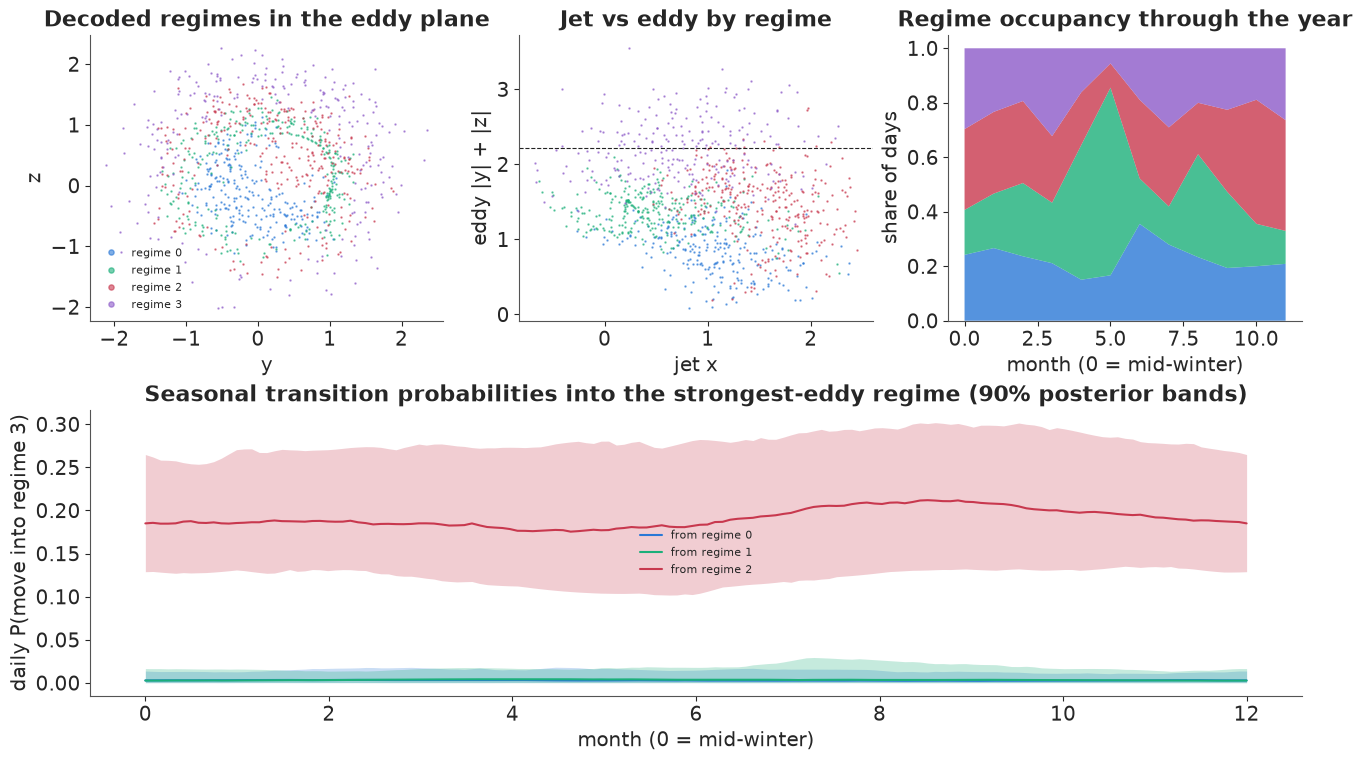

In [6]:
model_best, idata_best, _ = fits[K_BEST]
p_mean = params_from(idata_best)
filt_train, _, _ = forward_filter(p_mean, V[TRAIN], t_day[TRAIN])
regime = filt_train.argmax(1)
eddy_train = eddy_amplitude(days[1:TRAIN.stop])
w_danger = np.array([np.mean(eddy_train[regime == k] > E_STAR) for k in range(K_BEST)])
print(az.summary(idata_best, var_names=["level", "phi", "log_sd"], round_to=3)[["mean", "sd", "ess_bulk", "r_hat"]])
for k in range(K_BEST):
    print(f"regime {k}: {np.mean(regime == k):.0%} of days, mean jet {days[1:TRAIN.stop][regime == k, 0].mean():.2f}, "
          f"mean eddy {eddy_train[regime == k].mean():.2f}, share above E* (w_k) {w_danger[k]:.2f}")

season_grid = np.linspace(0, YEAR, 146)
trans_draws = np.array([[transition(p, tt) for tt in season_grid] for p in params_from(idata_best, n=200)])
fig = plt.figure(figsize=(13, 7.5))
gs = fig.add_gridspec(2, 3)
ax = fig.add_subplot(gs[0, 0])
for k in range(K_BEST):
    sel = regime == k
    ax.plot(days[1:TRAIN.stop][sel, 1], days[1:TRAIN.stop][sel, 2], ".", ms=1.5,
            color=STATE_COLOURS[k], alpha=0.6, label=f"regime {k}")
ax.set(xlabel="y", ylabel="z", title="Decoded regimes in the eddy plane")
ax.legend(fontsize=8, markerscale=5)
ax = fig.add_subplot(gs[0, 1])
for k in range(K_BEST):
    sel = regime == k
    ax.plot(days[1:TRAIN.stop][sel, 0], eddy_train[sel], ".", ms=1.5, color=STATE_COLOURS[k], alpha=0.6)
ax.axhline(E_STAR, color=INK, lw=0.8, ls="--")
ax.set(xlabel="jet x", ylabel="eddy |y| + |z|", title="Jet vs eddy by regime")
ax = fig.add_subplot(gs[0, 2])
occupancy = np.array([[np.mean(regime[(month[1:TRAIN.stop] == m)] == k) for m in range(12)]
                      for k in range(K_BEST)])
ax.stackplot(np.arange(12), occupancy, colors=STATE_COLOURS[:K_BEST], alpha=0.8)
ax.set(xlabel="month (0 = mid-winter)", ylabel="share of days", title="Regime occupancy through the year")
ax = fig.add_subplot(gs[1, :])
top = K_BEST - 1
for i in range(K_BEST):
    if i == top:
        continue
    q = np.quantile(trans_draws[:, :, i, top], [0.05, 0.5, 0.95], axis=0)
    ax.fill_between(season_grid / YEAR * 12, q[0], q[2], color=STATE_COLOURS[i], alpha=0.25, lw=0)
    ax.plot(season_grid / YEAR * 12, q[1], color=STATE_COLOURS[i], label=f"from regime {i}")
ax.set(xlabel="month (0 = mid-winter)", ylabel=f"daily P(move into regime {top})",
       title=f"Seasonal transition probabilities into the strongest-eddy regime (90% posterior bands)")
ax.legend(fontsize=8);

The regimes are interpretable. Regime 0 has small eddies; regimes 1 and 2 have similar,
moderate eddies but differ in the jet (weak in 1, strong in 2); regime 3 has the strongest
eddies and a weaker jet (the eddies have taken its energy), and it holds almost all days above
$E^*$: half its days are extreme, so its danger weight is $w_3 \approx 0.5$ and the others
are near 0. Regime 3's **occupancy** follows the season - about 30% of days in mid-winter, a
few per cent in early summer. The daily probability of *entering* it, though, is nearly flat
through the year: about 0.19 from regime 2 (with a wide posterior band), close to zero from
regimes 0 and 1. With three years of data the posterior puts the seasonality mainly into the
other transitions (how long regime 3 lasts, how often regime 2 is reached). Moves into danger
almost always go through regime 2, the strong-jet regime with moderate eddies.

## 5 · A danger score, and its link to local instability

The paper's trigger is a **danger score**: starting from today's filtered regime probabilities
$\alpha_t$, propagate them with the seasonal transition matrices, $\alpha_{t+h} = \alpha_t
P(t+1) \cdots P(t+h)$, and weight the probability of each regime by its share of extreme days:

$$\text{Danger}_t = \sum_{h=1}^{H} \frac1h \sum_k w_k\, [\alpha_{t+h}]_k, \qquad H = 5 \text{ days}.$$

Control is triggered when $\text{Danger}_t > D^*$. The paper reports that NHMM triggers coincide
with strongly positive local Lyapunov exponents. We check both that and a more basic property:
is the danger score a **calibrated** forecast of extremes over the next days?

share of days with LLE above its 90th percentile: high-danger days 0.40, other days 0.02
danger score vs realised share of extreme days in the next 5 days: correlation 0.35


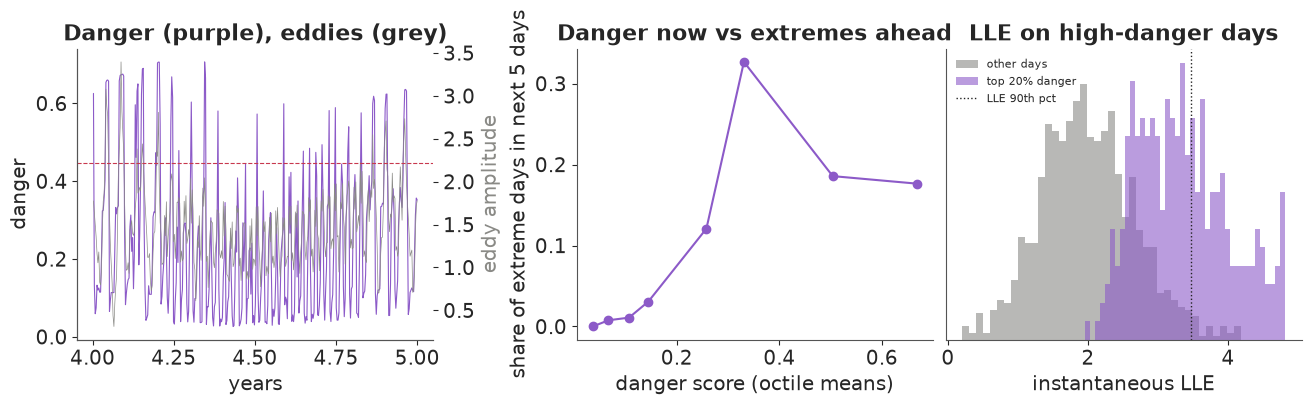

In [7]:
H_DAYS = 5


def danger(p, alpha, t):
    total, a = 0.0, alpha
    for h in range(1, H_DAYS + 1):
        a = a @ transition(p, t + 0.2 * h)
        total += (w_danger @ a) / h
    return total


eval_days = slice(4 * 365, 8 * 365)
filt_eval, _, _ = forward_filter(p_mean, V[eval_days.start - 1:eval_days.stop],
                                 t_day[eval_days.start - 1:eval_days.stop])
t_eval = t_day[eval_days]
danger_eval = np.array([danger(p_mean, a, tt) for a, tt in zip(filt_eval, t_eval)])
eddy_eval, lle_eval = eddy_day[eval_days], lle_day[eval_days]
# realised: any extreme day in the next H days?
ext = eddy_eval > E_STAR
future_ext = np.array([ext[i + 1:i + 1 + H_DAYS].mean() if i + 1 < len(ext) else np.nan
                       for i in range(len(ext))])
qbins = np.quantile(danger_eval, np.linspace(0, 1, 9))
b_of = np.clip(np.digitize(danger_eval, qbins) - 1, 0, 7)
calib = np.array([[danger_eval[b_of == b].mean(), np.nanmean(future_ext[b_of == b])] for b in range(8)])
lle_q90 = np.quantile(lle_day[:4 * 365], 0.9)

fig, axes = plt.subplots(1, 3, figsize=(13, 3.8))
ax = axes[0]
ax.plot(t_eval[:365] / YEAR, danger_eval[:365], color=PURPLE, lw=0.8, label="danger score")
ax2 = ax.twinx()
ax2.plot(t_eval[:365] / YEAR, eddy_eval[:365], color=GREY, lw=0.5)
ax2.axhline(E_STAR, color=RED, lw=0.8, ls="--")
ax2.set_ylabel("eddy amplitude", color=GREY)
ax.set(xlabel="years", ylabel="danger", title="Danger (purple), eddies (grey)")
ax = axes[1]
ax.plot(calib[:, 0], calib[:, 1], "o-", color=PURPLE)
ax.set(xlabel="danger score (octile means)", ylabel="share of extreme days in next 5 days",
       title="Danger now vs extremes ahead")
ax = axes[2]
for lo, hi, c in [(0, np.quantile(danger_eval, 0.8), GREY), (np.quantile(danger_eval, 0.8), np.inf, PURPLE)]:
    sel = (danger_eval >= lo) & (danger_eval < hi)
    ax.hist(lle_eval[sel], bins=40, density=True, color=c, alpha=0.6,
            label="top 20% danger" if c == PURPLE else "other days")
ax.axvline(lle_q90, color=INK, ls=":", lw=1, label="LLE 90th pct")
ax.set(xlabel="instantaneous LLE", yticks=[], title="LLE on high-danger days")
ax.legend(fontsize=8)
high = danger_eval > np.quantile(danger_eval, 0.8)
print(f"share of days with LLE above its 90th percentile: high-danger days {np.mean(lle_eval[high] > lle_q90):.2f}, "
      f"other days {np.mean(lle_eval[~high] > lle_q90):.2f}")
print(f"danger score vs realised share of extreme days in the next 5 days: correlation "
      f"{np.corrcoef(danger_eval[:-H_DAYS], future_ext[:-H_DAYS])[0, 1]:.2f}")

The danger score rises and falls with the eddy activity, but as a *forecast* it is not
monotone (middle panel). Extreme days in the next five days become more common as the score
rises to about 0.35, then *less* common in the top octiles. The highest scores come on days
the filter already places in regime 3, when the eddy is at or past its peak and about to
decay. The score is partly a **nowcast** of being in the dangerous regime. Its correlation with
the realised share of extreme days ahead is modest (printout).

High-danger days are much more often days of high local instability (40% vs 2% above the
LLE's 90th percentile), which reproduces the paper's observation. That is less surprising
than it sounds: section 1 showed that the LLE tracks the eddy amplitude (correlation 0.90), so
any indicator of strong eddies lines up with high LLE.

## 6 · Control through the NHMM - and the tests it has to pass

The paper's controller, as we implement it: each day, filter the regime probabilities from the
noisy observation; if the danger score exceeds $D^*$, choose the nudge $u$ to the state that
minimises

$$\text{Danger}_t(u) + \lambda \lVert u \rVert^2, \qquad \lVert u \rVert_\infty \le \varepsilon = 0.1,
  \quad \lambda = 10^{-3},$$

where $\text{Danger}_t(u)$ is computed with the regime probabilities the NHMM would assign to
the nudged state $x_t + u$. Then apply $u$ to the **true** Lorenz-84 system and let it evolve for
a day, with a little process noise so that repeated runs differ. The NHMM never sees the
equations: it acts only through what it learned about regimes.

Whether the result is an achievement depends on the comparison. We run every strategy on the
same 12 years of fresh weather (12 parallel one-year runs from different starting states and
noise) and count the share of time steps with eddy amplitude above $E^*$:

- **no control**;
- **NHMM control** at two danger thresholds (triggering more or less often);
- a **placebo**: whenever NHMM control acts, apply a nudge of the *same size* in a *random*
  direction. If this works as well, the benefit comes from shaking the system, not from the
  model;
- a **simple threshold rule** that needs no model: when the observed eddy amplitude is above a
  level, nudge the state by the same $\varepsilon = 0.1$ per component, strengthening the jet and
  shrinking the eddy ($+\varepsilon$ on $x$, $-\varepsilon$ along the eddy's direction in the
  $(y, z)$ plane);
- the same rule triggered by **instability** instead (LLE above its 90th percentile).

(34 s)
no control                   extreme share 0.087 (change   +0%, worse than no control in 0% of runs)   eddy 99th pct 2.87   nudges/year     0   energy 0.00
NHMM, D* = 0.3               extreme share 0.058 (change  -33%, worse than no control in 8% of runs)   eddy 99th pct 2.58   nudges/year   157   energy 4.39
placebo for D* = 0.3         extreme share 0.107 (change  +23%, worse than no control in 83% of runs)   eddy 99th pct 2.99   nudges/year   132   energy 3.53
NHMM, D* = 0.45              extreme share 0.040 (change  -54%, worse than no control in 0% of runs)   eddy 99th pct 2.43   nudges/year    59   energy 1.71
placebo for D* = 0.45        extreme share 0.109 (change  +25%, worse than no control in 83% of runs)   eddy 99th pct 2.95   nudges/year    75   energy 1.98
threshold rule, eddy > 2.0   extreme share 0.055 (change  -37%, worse than no control in 0% of runs)   eddy 99th pct 2.49   nudges/year    59   energy 1.19
LLE rule, LLE > 90th pct     extreme share 0.082 (chang

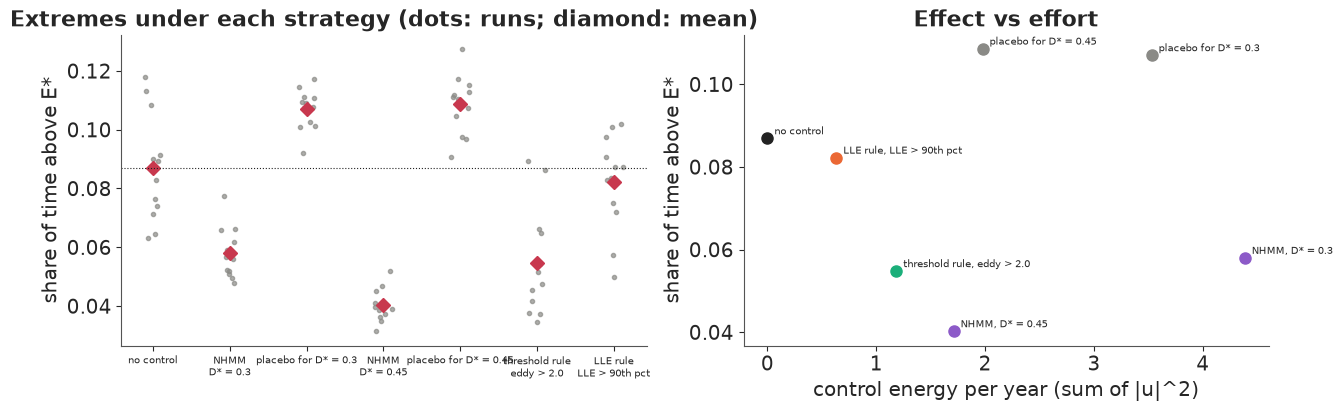

In [8]:
N_RUNS, RUN_DAYS, EPS, LAM = 12, 365, 0.1, 1e-3


def run_strategy(strategy, threshold=None, seed=7):
    """One year per run, N_RUNS runs; returns exceedance share, eddy 99th pct, triggers, energy."""
    r = np.random.default_rng(seed)
    results = []
    for run in range(N_RUNS):
        rr = np.random.default_rng(r.integers(1 << 32))
        s = days[4 * 365 + 30 * run] + 0.01 * rr.standard_normal(3)
        t = t_day[4 * 365 + 30 * run]
        la = np.log(np.full(K_BEST, 1 / K_BEST))
        v_prev = features(s * (1 + 0.05 * rr.standard_normal(3)))
        eddies, n_trig, energy = [], 0, 0.0
        for d in range(RUN_DAYS):
            seen = s * (1 + 0.05 * rr.standard_normal(3)) + 0.02 * rr.standard_normal(3)
            v = features(seen)
            pred = logsumexp(la[:, None] + np.log(transition(p_mean, t)), axis=0)
            joint = emission_logp(p_mean, v, v_prev) + pred
            la = joint - logsumexp(joint)
            u = np.zeros(3)
            if strategy in ("nhmm", "placebo") and danger(p_mean, np.exp(la), t) > threshold:
                def objective(uu):
                    j = emission_logp(p_mean, features(seen + uu), v_prev) + pred
                    return danger(p_mean, np.exp(j - logsumexp(j)), t) + LAM * uu @ uu
                u = minimize(objective, np.zeros(3), method="L-BFGS-B", bounds=[(-EPS, EPS)] * 3).x
                if strategy == "placebo":
                    direction = rr.standard_normal(3)
                    u = direction / np.linalg.norm(direction) * np.linalg.norm(u)
            elif strategy in ("threshold", "lle"):
                fire = (eddy_amplitude(seen) > threshold if strategy == "threshold"
                        else local_lyapunov(seen) > threshold)
                if fire:
                    amp = np.hypot(seen[1], seen[2])
                    u = np.array([EPS, -EPS * seen[1] / amp, -EPS * seen[2] / amp])
            n_trig += bool(np.any(u))
            energy += u @ u
            s = s + u
            v_prev = features(seen + u) if np.any(u) else v
            for _ in range(STEPS_PER_DAY):
                s = rk4(s, t)
                t += DT
                s = s + 0.002 * np.abs(s) * rr.standard_normal(3)
                eddies.append(eddy_amplitude(s))
        eddies = np.array(eddies)
        results.append((np.mean(eddies > E_STAR), np.quantile(eddies, 0.99), n_trig, energy))
    return np.array(results)


t0 = time.time()
strategies = [("no control", "none", None), ("NHMM, D* = 0.3", "nhmm", 0.3),
              ("placebo for D* = 0.3", "placebo", 0.3), ("NHMM, D* = 0.45", "nhmm", 0.45),
              ("placebo for D* = 0.45", "placebo", 0.45), ("threshold rule, eddy > 2.0", "threshold", 2.0),
              ("LLE rule, LLE > 90th pct", "lle", lle_q90)]
control = {name: run_strategy(kind, thr) for name, kind, thr in strategies}
print(f"({time.time() - t0:.0f} s)")
base = control["no control"][:, 0]
for name, res in control.items():
    print(f"{name:<28} extreme share {res[:, 0].mean():.3f} (change {100 * (res[:, 0].mean() / base.mean() - 1):+4.0f}%, "
          f"worse than no control in {np.mean(res[:, 0] > base):.0%} of runs)   eddy 99th pct {res[:, 1].mean():.2f}   "
          f"nudges/year {res[:, 2].mean():5.0f}   energy {res[:, 3].mean():.2f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
names = list(control)
ax = axes[0]
for i, name in enumerate(names):
    ax.plot(np.full(N_RUNS, i) + rng.uniform(-0.12, 0.12, N_RUNS), control[name][:, 0], "o", ms=3,
            color=GREY, alpha=0.7)
    ax.plot(i, control[name][:, 0].mean(), "D", color=RED, ms=7)
ax.axhline(base.mean(), color=INK, lw=0.8, ls=":")
ax.set_xticks(range(len(names)), [n.replace(", ", "\n") for n in names], fontsize=7)
ax.set(ylabel="share of time above E*", title="Extremes under each strategy (dots: runs; diamond: mean)")
ax = axes[1]
for name, c in zip(names, [INK, PURPLE, GREY, PURPLE, GREY, AQUA, ORANGE]):
    res = control[name]
    ax.plot(res[:, 3].mean(), res[:, 0].mean(), "o", color=c, ms=8)
    ax.annotate(name, (res[:, 3].mean(), res[:, 0].mean()), textcoords="offset points", xytext=(5, 3), fontsize=7)
ax.set(xlabel="control energy per year (sum of |u|^2)", ylabel="share of time above E*",
       title="Effect vs effort");

What the experiment says (the numbers are in the printout):

- **NHMM control works, and here it is the best strategy.** With $D^* = 0.45$ it roughly halves
  the share of time with extreme eddies (-54%), never doing worse than no control in the 12
  runs, and lowers the
  99th percentile of the eddy amplitude. It nudges on about 60 days a year - selective, though
  not the "2.5% of steps" of the paper's dashboard, which counts integration steps rather
  than days.
- **The placebo makes things worse.** Random nudges of the same size at the same moments
  *raise* the share of extremes by 20-25%, worse than no control in most runs. Timing
  alone does nothing useful: the NHMM's benefit comes from the *direction* it chooses.
  Hitting a system that is about to enter its dangerous regime in a random direction more
  often helps it in than out.
- **A one-line physical rule gets a large part of the way.** Nudging the jet up and the eddy
  down whenever the observed eddy exceeds 2.0 cuts extremes by 37%, with as many nudges and
  less energy. The NHMM does better because it acts earlier and on more informative days:
  it recognises regime 2, the gateway to regime 3, rather than waiting for large eddies.
- **Triggering on instability is not enough.** The same physical nudge triggered by the LLE
  (above its 90th percentile) barely helps (-5%) and is worse than no control in a third of
  the runs. High local instability comes with strong eddies, so it fires late, and it misses
  the build-up the NHMM sees.
- **More triggering is not better.** The lower threshold $D^* = 0.3$ nudges almost three
  times as often, for more than twice the energy, and achieves less (-33%). The danger score
  is not monotone (section 5), and many of the extra nudges come on days that were not heading
  for danger. With 12 runs this difference is clear (compare the dots), but the best threshold
  would be worth tuning on held-out weather, not on the runs used to report results.

The broader lesson is about evidence. The NHMM controller's advantage became visible only
against a placebo (showing that direction matters), a simple physical baseline (showing how
much is gained over common sense) and an alternative trigger (showing that instability alone
does not identify the right moments), all on the same weather, over many runs. A single
controlled trajectory next to an uncontrolled one, the usual figure in chaos-control papers,
cannot tell these apart.

## Summary

- A **nonautonomous** chaotic system has a seasonally changing attractor; in the seasonal
  Lorenz-84 model eddy extremes concentrate in winter and coincide with high local instability
  (section 1).
- **Choose regime variables with care**: eddy phase is not a regime; jet strength and eddy
  amplitude are (section 2).
- A **Bayesian NHMM** with seasonal softmax transitions and AR(1) emissions is a few lines of
  PyMC around the forward algorithm, but its likelihood is multimodal: multi-start
  optimisation, a shared start at the best optimum, and $\hat R$ across chains (section 3).
- The number of regimes can be chosen by the **held-out one-step log score**, and the posterior
  gives **seasonal transition curves with uncertainty** (section 4).
- The **danger score** lines up with high LLE - as expected, because both follow the eddy
  amplitude - but as a forecast of extremes ahead it is not monotone: its top values are
  partly a nowcast (section 5).
- **NHMM-triggered control** halves eddy extremes at a well-chosen threshold, beats a one-line
  physical rule and an LLE-triggered rule, and a same-size random placebo makes extremes
  *worse* - the direction of the nudge, learned by the regime model, is what matters
  (section 6).

## Try it yourself

1. **Posterior-averaged control.** The controller above uses the posterior-mean NHMM. Average the
   danger score over 20 posterior draws instead (the regime probabilities of each draw propagated
   separately). Does accounting for parameter uncertainty change how often the controller acts,
   or its effect?
2. **The paper's variables.** Refit the NHMM on $(x, y, z)$ as the paper does, starting the chains
   from a multi-start MAP. Do the regimes still separate eddy strength, and how does the
   NHMM-triggered control compare with the version above?
3. **A regime model with physics in it.** Replace the AR(1) emissions by one-day-ahead
   predictions from the Lorenz-84 equations themselves, with regime-specific forcing $F_k$ (a
   switching state-space model). Is the danger score better calibrated (monotone), and does
   control through this model beat the purely statistical NHMM?